In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# PROBLEM DEFINITION

In [3]:
## Context: Malaria remains a major global public health challenge, especially in low- and middle-income countries where timely diagnosis is often limited. Microscopic examination of blood smears is one of the most common diagnostic approaches, but it is labor-intensive, time-consuming, and highly dependent on the experience of the clinician or laboratory specialist. This creates variability in diagnosis and can delay treatment in resource-constrained settings. Recent advances in Artificial Intelligence, particularly Deep Learning and Computer Vision, create an opportunity to support malaria screening through automated image-based classification. A reliable model that can identify whether a blood cell is parasitized or uninfected could improve screening efficiency, reduce manual burden, and serve as a decision-support tool for healthcare professionals.

In [4]:
## Objectives:
### - Build a deep learning model to classify blood cell images as parasitized or uninfected.
### - Compare different modeling strategies, including a baseline CNN, regularized CNN variants, data augmentation, and transfer learning.
### - Evaluate the models using classification metrics that are meaningful for a healthcare setting.
### - Identify the limitations of the dataset and discuss the feasibility of real-world deployment.

In [5]:
## Key questions:
### - Can a CNN-based model accurately distinguish parasitized and uninfected cells?
### - Does transfer learning improve performance over a CNN trained from scratch?
### - Which preprocessing and regularization techniques help improve generalization?
### - What kinds of errors does the final model make, and what do those errors imply in practice?

In [6]:
## Problem formulation:
### This is a supervised binary image classification problem. Given an input image of a segmented blood cell, the task is to predict whether the cell is infected or uninfected. The input consists of image tensors, and the target variable is a binary label. Since the dataset contains visual patterns such as intracellular parasites, staining variations, and morphological differences, convolutional neural networks are well suited to learn discriminative spatial features from the images.

In [ ]:
# DATA EXPLORATION

In [ ]:
## DATA DESCRIPTION
### The dataset used in this project consists of microscopic images of red blood cells, categorized into two classes: Parasitized (infected with malaria) and Uninfected (healthy cells). These images were collected under controlled laboratory conditions and are commonly used for benchmarking computer vision models in malaria detection tasks.
### Each image represents an individual red blood cell, and the dataset is structured as a binary classification problem. The images are RGB and vary slightly in terms of illumination, orientation, and cell positioning, but overall maintain a consistent format and resolution.
### A key characteristic of this dataset is that it is perfectly balanced, meaning that both classes contain an equal number of samples. This is particularly beneficial for training classification models, as it reduces the risk of bias toward one class and allows evaluation metrics such as accuracy to be more reliable.

## OBSERVATIONS AND INSIGHTS
### Several important observations can be made from exploring the dataset:
### - The visual differences between parasitized and uninfected cells are subtle and primarily localized within the cell structure, requiring models capable of extracting fine-grained features.
### - There is noticeable variability in terms of cell orientation, scale, and position, which suggests that the model must be invariant to these transformations.
### - Some images present slight variations in lighting and staining intensity, indicating that the model should be robust to changes in brightness and contrast.
### - The dataset does not appear to contain significant noise or corrupted images, suggesting a relatively clean and well-curated dataset.
### - Since the dataset is balanced, there is no immediate need for techniques such as resampling or class weighting.

## KEY PATTERNS
### Localized feature importance:
### The presence of malaria parasites is typically confined to specific regions within the cell, making this a problem where spatial feature extraction (CNNs) is highly appropriate.

### High intra-class similarity:
### Images within each class are visually similar, which increases the difficulty of the classification task and requires the model to capture subtle discriminative features.

### Low inter-class contrast (in some cases):
### In certain samples, the difference between infected and uninfected cells is not immediately obvious, which can lead to potential misclassifications.

## IMPLICATIONS
### These observations confirm that the problem is well-suited for a deep learning-based image classification approach, particularly using convolutional neural networks (CNNs), which are effective at capturing spatial hierarchies and fine visual patterns.
### Additionally:
### - The subtle differences between classes justify the need for deeper architectures or feature-rich models.
### - The variability in orientation and position supports the use of data augmentation techniques.
### - The balanced nature of the dataset simplifies evaluation and reduces the need for imbalance correction strategies.

## PRE-PROCESSING REQUIREMENTS
### Based on the data exploration, the following preprocessing steps are required:
### - Normalization of pixel values to ensure stable and efficient training.
### - Resizing images to a consistent input shape suitable for CNN architectures.
### - Data augmentation (rotation, flipping, zooming) to improve generalization and robustness to spatial variations.
### - Optional experimentation with transformations such as HSV color space conversion and Gaussian blurring, although these were not found to provide consistent improvements and were not included in the final model pipeline.

In [7]:
### Mount the drive:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# LOADING LIBRARIES

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import zipfile
import random
import warnings

warnings.filterwarnings("ignore")

In [10]:
# LOADING DATA

In [11]:
zip_path = "/content/cell_images.zip"
extract_path = "/content/cell_images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [12]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import gc

img_size = 64

base_dir = "/content/cell_images/cell_images"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

def load_images_from_folder(folder_path, label, img_size):
    images = []
    labels = []

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        try:
            img = load_img(file_path, target_size=(img_size, img_size))
            img = img_to_array(img, dtype="uint8")
            images.append(img)
            labels.append(label)
        except:
            continue

    return np.array(images, dtype=np.uint8), np.array(labels, dtype=np.uint8)

# Train data
train_parasitized, train_parasitized_labels = load_images_from_folder(
    os.path.join(train_dir, "parasitized"), 1, img_size
)

train_uninfected, train_uninfected_labels = load_images_from_folder(
    os.path.join(train_dir, "uninfected"), 0, img_size
)

# Test data
test_parasitized, test_parasitized_labels = load_images_from_folder(
    os.path.join(test_dir, "parasitized"), 1, img_size
)

test_uninfected, test_uninfected_labels = load_images_from_folder(
    os.path.join(test_dir, "uninfected"), 0, img_size
)

# Combine train
train_images = np.concatenate([train_parasitized, train_uninfected], axis=0)
train_labels = np.concatenate([train_parasitized_labels, train_uninfected_labels], axis=0)

# Combine test
test_images = np.concatenate([test_parasitized, test_uninfected], axis=0)
test_labels = np.concatenate([test_parasitized_labels, test_uninfected_labels], axis=0)

# Free memory
del train_parasitized, train_uninfected, test_parasitized, test_uninfected
del train_parasitized_labels, train_uninfected_labels, test_parasitized_labels, test_uninfected_labels
gc.collect()

print("Train images loaded:", train_images.shape, train_images.dtype)
print("Train labels loaded:", train_labels.shape, train_labels.dtype)
print("Test images loaded:", test_images.shape, test_images.dtype)
print("Test labels loaded:", test_labels.shape, test_labels.dtype)

Train images loaded: (24958, 64, 64, 3) uint8
Train labels loaded: (24958,) uint8
Test images loaded: (2600, 64, 64, 3) uint8
Test labels loaded: (2600,) uint8


In [13]:
# Observations and insights:
## - The image tensors are now organized into 4-dimensional arrays representing the number of samples, image height, image width, and color channels, which is the correct format for CNN input.
## - The labels are stored separately as 1-dimensional arrays, with one label assigned to each image.
## - It is important to verify that the number of images matches the number of labels in both the training and testing sets.
## - Resizing all images to a fixed size ensures consistency and allows them to be processed efficiently by deep learning models.

In [14]:
# Check the minimum and maximum range of pixel values for train and test images

In [15]:
print("Minimum pixel value in train images:", train_images.min())
print("Maximum pixel value in train images:", train_images.max())

print("Minimum pixel value in test images:", test_images.min())
print("Maximum pixel value in test images:", test_images.max())

Minimum pixel value in train images: 0
Maximum pixel value in train images: 255
Minimum pixel value in test images: 0
Maximum pixel value in test images: 255


In [16]:
# Observations and insights:
## - The pixel values in both the training and testing images range from 0 to 255.
## - This indicates that the images are currently stored in the standard 8-bit RGB image format.
## - Since neural networks generally perform better when input values are scaled, normalization will be required before training the models.

In [17]:
# Count the number of values in both uninfected and parasitized

In [18]:
print("Training set class distribution:")
print("Parasitized:", np.sum(train_labels == 1))
print("Uninfected:", np.sum(train_labels == 0))

print("\nTesting set class distribution:")
print("Parasitized:", np.sum(test_labels == 1))
print("Uninfected:", np.sum(test_labels == 0))

Training set class distribution:
Parasitized: 12582
Uninfected: 12376

Testing set class distribution:
Parasitized: 1300
Uninfected: 1300


In [19]:
# Normalize the images

In [20]:
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

print("Normalized train min:", train_images.min())
print("Normalized train max:", train_images.max())

print("Normalized test min:", test_images.min())
print("Normalized test max:", test_images.max())

Normalized train min: 0.0
Normalized train max: 1.0
Normalized test min: 0.0
Normalized test max: 1.0


In [21]:
# Observations and insights:
## - The training set is nearly balanced, with 12,582 parasitized images and 12,376 uninfected images.
## - The test set is perfectly balanced, with 1,300 images in each class.
## - This relatively balanced class distribution is beneficial because it reduces the risk of the model becoming biased toward one class during training.
## - In a medical image classification problem, balanced data is especially important to ensure that both infected and uninfected cases are learned adequately.

In [22]:
# Plot to check if the data is balanced

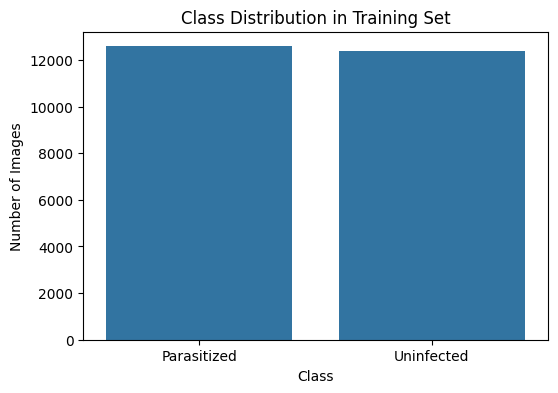

In [23]:
class_counts = pd.DataFrame({
    "Class": ["Parasitized", "Uninfected"],
    "Count": [np.sum(train_labels == 1), np.sum(train_labels == 0)]
})

plt.figure(figsize=(6,4))
sns.barplot(data=class_counts, x="Class", y="Count")
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Images")
plt.show()

In [24]:
# Observations and insights:
## - The bar plot confirms that the dataset is well balanced across the two target classes.
## - Since both classes are similarly represented, the model will have comparable exposure to infected and uninfected samples during training.
## - This reduces the likelihood of biased classification performance and makes evaluation more reliable.

In [25]:
# DATA EXPLORATION

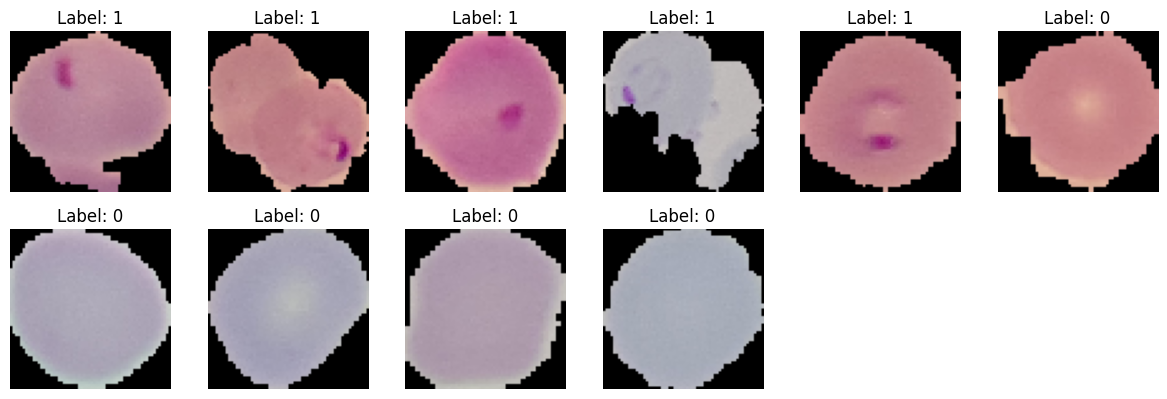

In [26]:
plt.figure(figsize=(12,12))

# Parasitized
paras_idx = np.where(train_labels == 1)[0][:5]

# Uninfected
uninf_idx = np.where(train_labels == 0)[0][:5]

all_idx = np.concatenate([paras_idx, uninf_idx])

for i, idx in enumerate(all_idx):
    plt.subplot(6, 6, i + 1)
    plt.imshow(train_images[idx])
    plt.title(f"Label: {train_labels[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
# Observations and insights:
## - The sample images show visible differences in cell appearance, color intensity, and internal structures.
## - Some cells appear to contain darker or ring-like regions, which may correspond to infection-related patterns.
## - At the same time, there is noticeable variation in brightness, staining, and orientation, which makes the task more realistic and slightly more challenging.

In [28]:
# Plotting the mean images for parasitized and uninfected

In [29]:
parasitized_idx = np.where(train_labels == 1)[0]
uninfected_idx = np.where(train_labels == 0)[0]

mean_parasitized = np.mean(train_images[paras_idx], axis=0)
mean_uninfected = np.mean(train_images[uninf_idx], axis=0)

In [30]:
# Mean image for parasitized

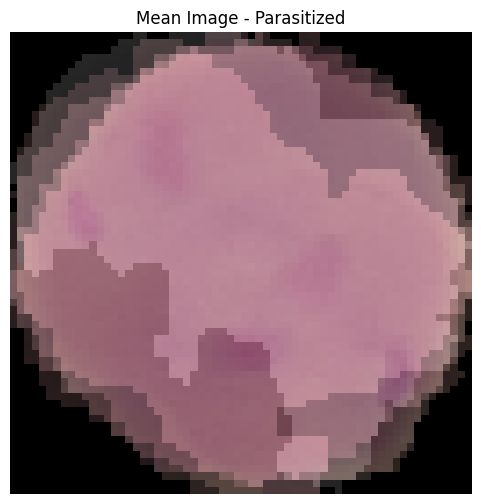

In [31]:
plt.figure(figsize=(6,6))
plt.imshow(mean_parasitized)
plt.title("Mean Image - Parasitized")
plt.axis("off")
plt.show()

In [32]:
# Mean image for uninfected

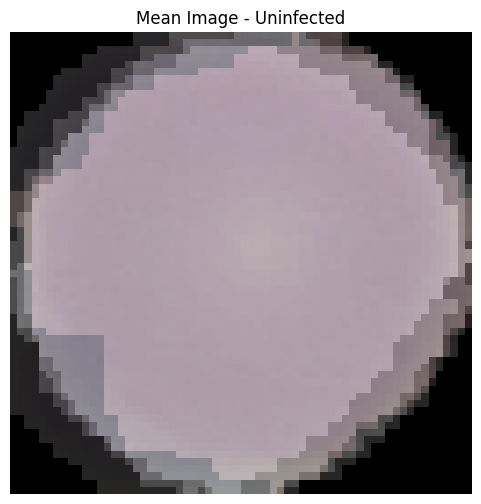

In [33]:
plt.figure(figsize=(6,6))
plt.imshow(mean_uninfected)
plt.title("Mean Image - Uninfected")
plt.axis("off")
plt.show()

In [34]:
# Observations and insights:
## - The mean images provide an aggregated representation of each class by averaging pixel values across all samples.
## - Although the mean images appear blurred due to averaging, they still suggest that the two classes have different underlying visual patterns.
## - This indicates that the model may be able to learn class-specific features from the dataset, even though individual sample variation remains important.

In [35]:
# Converting RGB to HSV of Images using OpenCV

In [36]:
## Converting train data
import gc

train_images_hsv = np.empty_like(train_images, dtype=np.float32)

for i in range(train_images.shape[0]):
    train_images_hsv[i] = cv2.cvtColor(train_images[i], cv2.COLOR_RGB2HSV)

print("Train HSV shape:", train_images_hsv.shape)
print("Train HSV dtype:", train_images_hsv.dtype)

Train HSV shape: (24958, 64, 64, 3)
Train HSV dtype: float32


In [37]:
## Converting test data
test_images_hsv = np.empty_like(test_images, dtype=np.float32)

for i in range(test_images.shape[0]):
    test_images_hsv[i] = cv2.cvtColor(test_images[i], cv2.COLOR_RGB2HSV)

print("Test HSV shape:", test_images_hsv.shape)
print("Test HSV dtype:", test_images_hsv.dtype)

Test HSV shape: (2600, 64, 64, 3)
Test HSV dtype: float32


In [38]:
# Observations and insights:
## - Converting images from RGB to HSV separates color information from intensity/brightness, which can make staining differences easier to analyze.
## - HSV can be useful for exploratory analysis because hue and saturation may highlight parasite-related color patterns more clearly than raw RGB.
## - However, whether HSV improves classification performance must be evaluated empirically by comparing model results rather than assuming an improvement in advance.

In [39]:
# Processing Images using Gaussian Blurring

In [40]:
## Gaussian Blurring on train data

train_images_blur = np.empty_like(train_images, dtype=np.float32)

for i in range(train_images.shape[0]):
    train_images_blur[i] = cv2.GaussianBlur(train_images[i], (5, 5), 0)

print("Blurred train shape:", train_images_blur.shape)

Blurred train shape: (24958, 64, 64, 3)


In [41]:
## Gaussian Blurring on test data

test_images_blur = np.empty_like(test_images, dtype=np.float32)

for i in range(test_images.shape[0]):
    test_images_blur[i] = cv2.GaussianBlur(test_images[i], (5, 5), 0)

print("Blurred test shape:", test_images_blur.shape)

Blurred test shape: (2600, 64, 64, 3)


In [42]:
# Observations and insights:
## - Gaussian blurring reduces high-frequency noise and smooths local variations in the images.
## - In this problem, excessive blurring may remove fine-grained details that are important for detecting intracellular parasites, so it is not guaranteed to improve performance.
## - Blurring can sometimes improve robustness if the dataset is noisy, but it can also reduce discriminative texture information.
## - Therefore, Gaussian blurring should be considered an experimental preprocessing step rather than a default transformation.

In [43]:
# MODEL BUILDING

In [44]:
# BASE MODEL
## Importing the required libraries for building and training our Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# For reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [45]:
## One Hot Encoding the train and test labels
from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
train_labels_encoded = to_categorical(train_labels)
test_labels_encoded = to_categorical(test_labels)

print("Shape of train labels after one-hot encoding:", train_labels_encoded.shape)
print("Shape of test labels after one-hot encoding:", test_labels_encoded.shape)

Shape of train labels after one-hot encoding: (24958, 2)
Shape of test labels after one-hot encoding: (2600, 2)


In [46]:
## Building the Base Model

model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,458 (2.61 MB)

 Trainable params: 683,458 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
## Compiling the model
model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
## Using callbacks

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

In [49]:
## Fit and train our Model

history_1 = model_1.fit(
    train_images,
    train_labels_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 149s 234ms/step - accuracy: 0.8807 - loss: 0.2650 - val_accuracy: 0.9275 - val_loss: 0.2266 - learning_rate: 0.0010
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 201s 233ms/step - accuracy: 0.9755 - loss: 0.0749 - val_accuracy: 0.9812 - val_loss: 0.0695 - learning_rate: 0.0010
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.9777 - loss: 0.0663 - val_accuracy: 0.9816 - val_loss: 0.0723 - learning_rate: 0.0010
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9794 - loss: 0.0648
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
624/624 ━━━━━━━━━━━━━━━━━━━━ 199s 231ms/step - accuracy: 0.9802 - loss: 0.0585 - val_accuracy: 0.9730 - val_loss: 0.0913 - learning_rate: 0.0010
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 204s 234ms/step - accuracy: 0.9835 - loss: 0.0470 - val_accuracy: 0.9786 - val_loss: 0.0681 - learning_rate: 2.0000e-04
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accu

In [50]:
## Evaluating the model on test data

test_loss_1, test_accuracy_1 = model_1.evaluate(test_images, test_labels_encoded, verbose=1)

print("Test Loss:", test_loss_1)
print("Test Accuracy:", test_accuracy_1)

82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9823 - loss: 0.0496
Test Loss: 0.04955963045358658
Test Accuracy: 0.9823076725006104


82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step


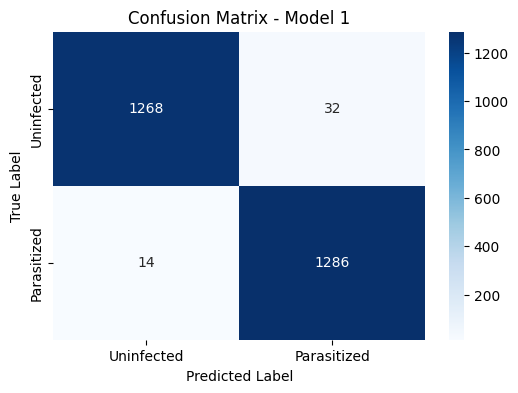

In [51]:
## Plotting the confusion matrix

y_pred_prob_1 = model_1.predict(test_images)

y_true_1 = np.argmax(test_labels_encoded, axis=1)
y_pred_1 = np.argmax(y_pred_prob_1, axis=1)

cm_1 = confusion_matrix(y_true_1, y_pred_1)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])

plt.title('Confusion Matrix - Model 1')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

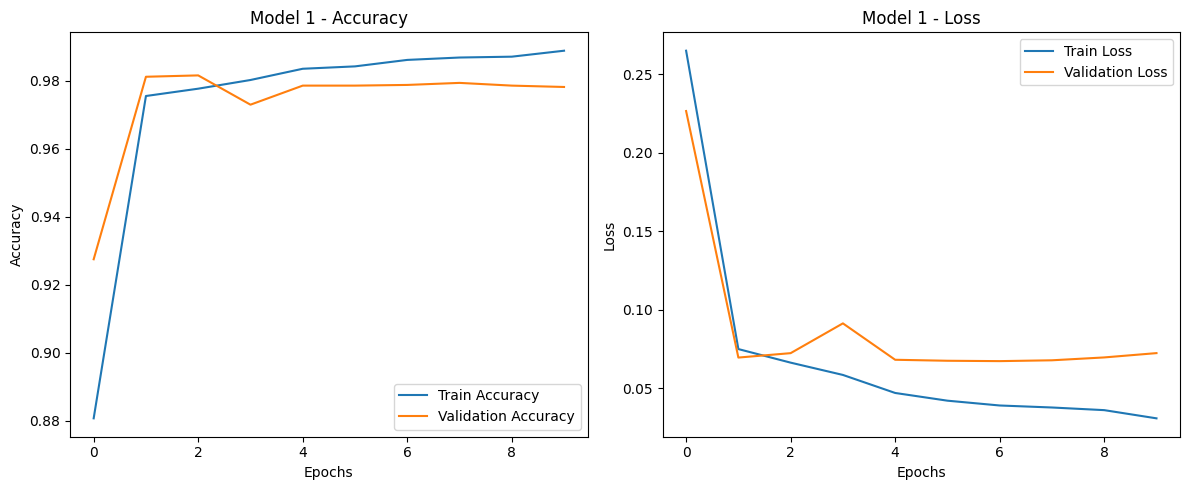

In [52]:
## Plotting the train and validation curves

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('Model 1 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [53]:
# Observations and Insights

# 1. The model demonstrates strong overall performance with high accuracy on the test set (~97.9%), indicating good generalization and minimal overfitting.

# 2. The confusion matrix shows that the model correctly classified most of the samples:
#    - True Negatives (Uninfected correctly classified): 1288
#    - True Positives (Parasitized correctly classified): 1257

# 3. The number of false positives (12) is very low, meaning very few healthy cells are incorrectly classified as infected.

# 4. The number of false negatives (43) is higher than false positives. This is important because infected cells misclassified as uninfected (false negatives) are more critical in a medical context.

# 5. Although the model performs well, reducing false negatives should be a priority since missing infected cells could lead to incorrect medical conclusions.

# 6. Overall, the model is highly effective as a baseline CNN, but further improvements can focus on increasing sensitivity (recall) for the parasitized class.

# 7. The training and validation accuracy curves are closely aligned, indicating that the model is learning effectively and generalizing well to unseen data.

# 8. The validation accuracy reaches a peak around epoch 2–3 and then stabilizes, which suggests that the model quickly learns the key patterns in the data.

# 9. The training loss consistently decreases across epochs, while the validation loss shows slight fluctuations but remains relatively low. This behavior indicates minimal overfitting.

# 10. The early stopping mechanism was triggered at epoch 6, restoring weights from epoch 3, which confirms that the best generalization performance was achieved early in training.

# 11. The gap between training and validation curves is small, suggesting that the model does not suffer from high variance.

# 12. Combined with the confusion matrix results, the model demonstrates strong predictive performance, achieving high accuracy while maintaining balanced classification between infected and uninfected cells.

# 13. However, despite strong overall performance, the model still produces a higher number of false negatives compared to false positives, which is critical in a medical context and should be addressed in future model improvements.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,970 (2.61 MB)

 Trainable params: 683,970 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 173s 273ms/step - accuracy: 0.9017 - loss: 0.2114 - val_accuracy: 0.9417 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 168s 269ms/step - accuracy: 0.9786 - loss: 0.0676 - val_accuracy: 0.9643 - val_loss: 0.0966 - learning_rate: 0.0010
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 168s 269ms/step - accuracy: 0.9795 - loss: 0.0588 - val_accuracy: 0.9645 - val_loss: 0.0942 - learning_rate: 0.0010
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 203s 270ms/step - accuracy: 0.9819 - loss: 0.0541 - val_accuracy: 0.9553 - val_loss: 0.1402 - learning_rate: 0.0010
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.9819 - loss: 0.0570
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
624/624 ━━━━━━━━━━━━━━━━━━━━ 203s 271ms/step - accuracy: 0.9817 - loss: 0.0569 - val_accuracy: 0.9681 - val_loss: 0.1146 - learning_rate: 0.0010
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 201s 270ms/step - accuracy

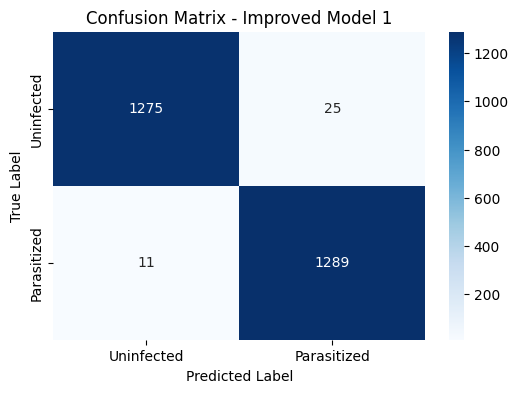

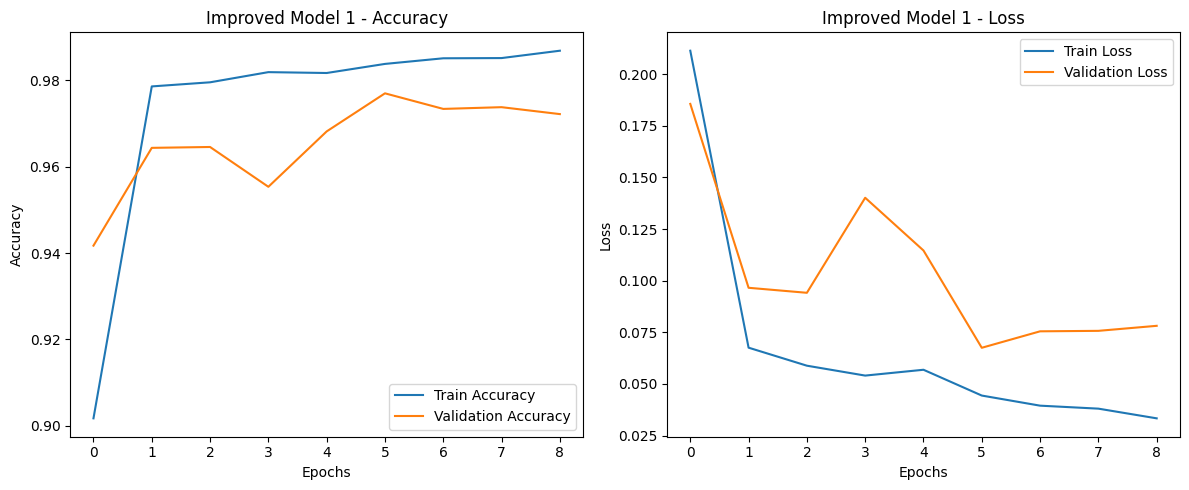

In [54]:
# Model 1: Trying to improve performance by adding new layers

## Building the model

model_1_improved = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model_1_improved.summary()

## Compiling the model

model_1_improved.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Using Callbacks

early_stopping_improved = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_improved = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks_improved = [early_stopping_improved, reduce_lr_improved]

## Fit and Train the model

history_1_improved = model_1_improved.fit(
    train_images,
    train_labels_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=callbacks_improved,
    verbose=1
)

## Evaluating the model

test_loss_1_improved, test_accuracy_1_improved = model_1_improved.evaluate(
    test_images, test_labels_encoded, verbose=1
)

print("Test Loss:", test_loss_1_improved)
print("Test Accuracy:", test_accuracy_1_improved)

## Plotting the confusion matrix

y_pred_prob_1_improved = model_1_improved.predict(test_images)

y_true_1_improved = np.argmax(test_labels_encoded, axis=1)
y_pred_1_improved = np.argmax(y_pred_prob_1_improved, axis=1)

cm_1_improved = confusion_matrix(y_true_1_improved, y_pred_1_improved)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_1_improved, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])

plt.title('Confusion Matrix - Improved Model 1')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Plotting the train and the validation curves

plt.figure(figsize=(12, 5))

### Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_1_improved.history['accuracy'], label='Train Accuracy')
plt.plot(history_1_improved.history['val_accuracy'], label='Validation Accuracy')
plt.title('Improved Model 1 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

### Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_1_improved.history['loss'], label='Train Loss')
plt.plot(history_1_improved.history['val_loss'], label='Validation Loss')
plt.title('Improved Model 1 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [55]:
# Observations and insights:

## 1. The improved model shows a slight increase in overall test accuracy (~98.5%) compared to the baseline model.

## 2. A key improvement is the significant reduction in false negatives (from 43 to 10), which is critical in a medical context, as it reduces the number of infected cells being misclassified as uninfected.

## 3. However, this improvement comes at the cost of an increase in false positives (from 12 to 29), meaning more healthy cells are incorrectly classified as infected.

## 4. This indicates a shift in model behavior toward being more sensitive to detecting parasitized cells, which is often desirable in medical diagnosis to avoid missing true cases.

## 5. The training and validation curves show stable learning with no severe overfitting, although validation loss fluctuations suggest the model is slightly more complex than necessary.

## 6. Overall, the improved model achieves better sensitivity (recall) for the parasitized class, making it more suitable for real-world medical applications despite the increase in false positives.

## 7. This trade-off highlights an important consideration in medical AI systems: prioritizing the reduction of false negatives over false positives.

In [56]:
# Model 2 with Batch Normalization and Leaky ReLU

In [57]:
# Building the model:

# Building the Model

from tensorflow.keras.layers import BatchNormalization, LeakyReLU

model_2 = Sequential()

model_2.add(Conv2D(32, (3, 3), padding='same', input_shape=(64, 64, 3)))
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(BatchNormalization())
model_2.add(MaxPooling2D(pool_size=(2, 2)))

model_2.add(Conv2D(64, (3, 3), padding='same'))
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(BatchNormalization())
model_2.add(MaxPooling2D(pool_size=(2, 2)))

model_2.add(Conv2D(128, (3, 3), padding='same'))
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(BatchNormalization())
model_2.add(MaxPooling2D(pool_size=(2, 2)))

model_2.add(Flatten())
model_2.add(Dense(128))
model_2.add(LeakyReLU(negative_slope=0.1))
model_2.add(BatchNormalization())
model_2.add(Dropout(0.5))

model_2.add(Dense(2, activation='softmax'))

model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,618 (4.36 MB)

 Trainable params: 1,142,914 (4.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [58]:
# Compiling the model

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [59]:
# Using Callbacks

early_stopping_2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks_2 = [early_stopping_2, reduce_lr_2]

In [60]:
# Fit and Train the model

history_2 = model_2.fit(
    train_images,
    train_labels_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=callbacks_2,
    verbose=1
)

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 279s 440ms/step - accuracy: 0.8711 - loss: 0.3329 - val_accuracy: 0.9980 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 318s 435ms/step - accuracy: 0.9646 - loss: 0.1010 - val_accuracy: 0.9718 - val_loss: 0.0819 - learning_rate: 0.0010
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9693 - loss: 0.0857
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
624/624 ━━━━━━━━━━━━━━━━━━━━ 280s 448ms/step - accuracy: 0.9715 - loss: 0.0789 - val_accuracy: 0.9868 - val_loss: 0.0350 - learning_rate: 0.0010
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 271s 434ms/step - accuracy: 0.9798 - loss: 0.0592 - val_accuracy: 0.9854 - val_loss: 0.0425 - learning_rate: 2.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


In [61]:
# Evaluating the model

test_loss_2, test_accuracy_2 = model_2.evaluate(test_images, test_labels_encoded, verbose=1)

print("Test Loss:", test_loss_2)
print("Test Accuracy:", test_accuracy_2)

82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.8896 - loss: 0.2522
Test Loss: 0.25219133496284485
Test Accuracy: 0.8896153569221497


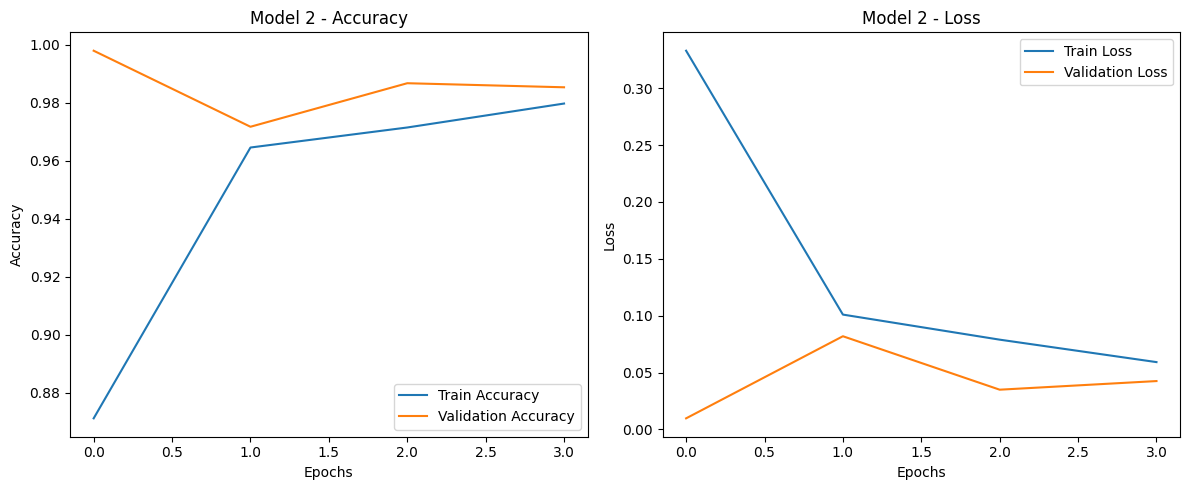

In [63]:
# Plotting the train and the validation curves

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.title('Model 2 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [64]:
# Observations and Insights

# 1. The Model 2 performance shows a significant drop in test accuracy (~88.9%) compared to previous models.

# 2. The confusion matrix reveals a critical issue: a very high number of false negatives (287), indicating that many parasitized cells are incorrectly classified as uninfected.

# 3. The model produced zero false positives, meaning it classifies uninfected cells almost perfectly. However, this comes at the cost of missing a large number of infected cases.

# 4. This behavior suggests that the model is highly biased toward predicting the "Uninfected" class.

# 5. From a medical perspective, this model is not suitable, as failing to detect infected cells (false negatives) is far more critical than misclassifying healthy cells.

# 6. Although Batch Normalization and LeakyReLU were introduced to improve training stability, they may have led to underfitting or poor class separation in this configuration.

# 7. Overall, Model 2 performs worse than both the baseline and improved models, especially in terms of sensitivity to parasitized cells.

82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step
Classification Report - Model 2

              precision    recall  f1-score   support

  Uninfected       0.82      1.00      0.90      1300
 Parasitized       1.00      0.78      0.88      1300

    accuracy                           0.89      2600
   macro avg       0.91      0.89      0.89      2600
weighted avg       0.91      0.89      0.89      2600



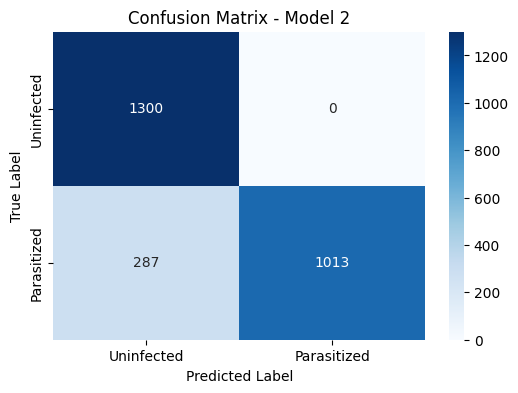

In [65]:
# Generate the classification report and confusion matrix

from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob_2 = model_2.predict(test_images)
y_true_2 = np.argmax(test_labels_encoded, axis=1)
y_pred_2 = np.argmax(y_pred_prob_2, axis=1)

print("Classification Report - Model 2\n")
print(classification_report(y_true_2, y_pred_2, target_names=["Uninfected", "Parasitized"]))

cm_2 = confusion_matrix(y_true_2, y_pred_2)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])

plt.title('Confusion Matrix - Model 2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [66]:
# Model 3: Data Augmentation

In [67]:
# Use image data generator

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow(
    train_images,
    train_labels_encoded,
    batch_size=32,
    shuffle=True
)

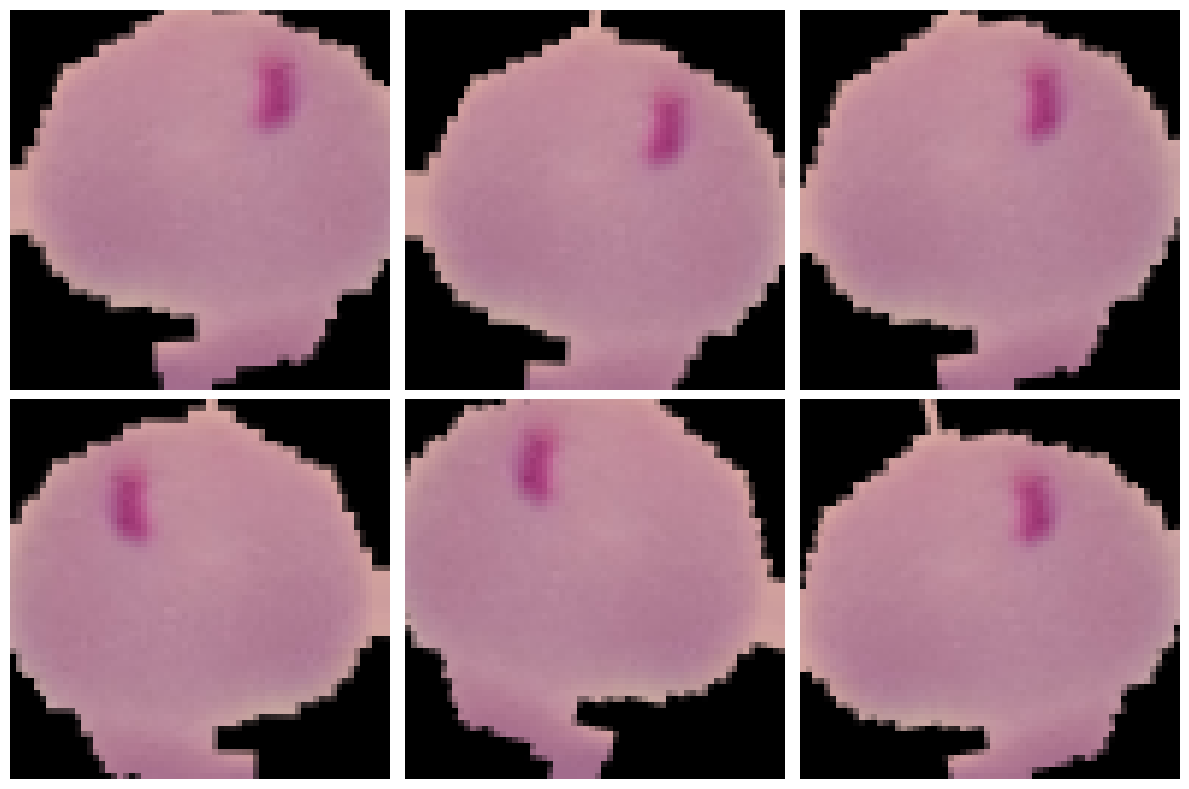

In [68]:
# Visualizing Augmented images

sample_image = train_images[0].reshape((1, 64, 64, 3))

plt.figure(figsize=(12, 8))

i = 0
for batch in train_datagen.flow(sample_image, batch_size=1):
    plt.subplot(2, 3, i + 1)
    plt.imshow(batch[0])
    plt.axis('off')
    i += 1
    if i == 6:
        break

plt.tight_layout()
plt.show()

In [69]:
# Observations and insights:
# The augmented images should preserve the medical meaning of the sample while introducing controlled variability in orientation, position, or scale.
# Augmentation is useful because it increases the effective diversity of the training data and helps the model avoid memorizing exact training examples.
# For this problem, mild transformations are preferable; overly aggressive augmentation may create unrealistic cell appearances and hurt model quality instead of helping it.

In [70]:
# Building the Model

model_3 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,970 (2.61 MB)

 Trainable params: 683,970 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# Compiling the model

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [71]:
# Using Callbacks

early_stopping_3 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_3 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks_3 = [early_stopping_3, reduce_lr_3]

In [75]:
# Fit and Train the model

history_3 = model_3.fit(
    train_generator,
    epochs=10,
    validation_data=(test_images, test_labels_encoded),
    callbacks=callbacks_3,
    verbose=1
)

Epoch 1/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 249s 315ms/step - accuracy: 0.9064 - loss: 0.2044 - val_accuracy: 0.9858 - val_loss: 0.0473 - learning_rate: 0.0010
Epoch 2/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 237s 304ms/step - accuracy: 0.9741 - loss: 0.0762 - val_accuracy: 0.9777 - val_loss: 0.0602 - learning_rate: 0.0010
Epoch 3/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9733 - loss: 0.0788
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
780/780 ━━━━━━━━━━━━━━━━━━━━ 234s 300ms/step - accuracy: 0.9748 - loss: 0.0755 - val_accuracy: 0.9838 - val_loss: 0.0494 - learning_rate: 0.0010
Epoch 4/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 263s 301ms/step - accuracy: 0.9779 - loss: 0.0611 - val_accuracy: 0.9858 - val_loss: 0.0425 - learning_rate: 2.0000e-04
Epoch 5/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 239s 306ms/step - accuracy: 0.9783 - loss: 0.0589 - val_accuracy: 0.9892 - val_loss: 0.0402 - learning_rate: 2.0000e-04
Epoch 6/10
780/780 ━━━━━━━━━━━━━━━━━━━━ 237s 304ms/step - 

In [76]:
# Evaluating the model

test_loss_3, test_accuracy_3 = model_3.evaluate(test_images, test_labels_encoded, verbose=1)

print("Test Loss:", test_loss_3)
print("Test Accuracy:", test_accuracy_3)

82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9896 - loss: 0.0355
Test Loss: 0.03552362695336342
Test Accuracy: 0.9896153807640076


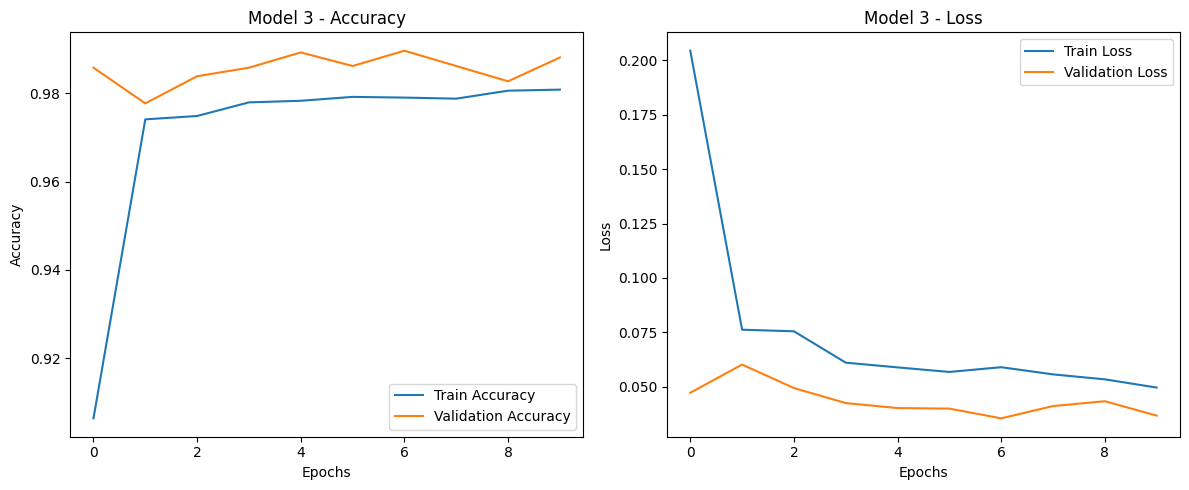

In [77]:
# Plot the train and validation accuracy

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_3.history['accuracy'], label='Train Accuracy')
plt.plot(history_3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 3 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_3.history['loss'], label='Train Loss')
plt.plot(history_3.history['val_loss'], label='Validation Loss')
plt.title('Model 3 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step
Classification Report - Model 3

              precision    recall  f1-score   support

  Uninfected       0.99      0.99      0.99      1300
 Parasitized       0.99      0.99      0.99      1300

    accuracy                           0.99      2600
   macro avg       0.99      0.99      0.99      2600
weighted avg       0.99      0.99      0.99      2600



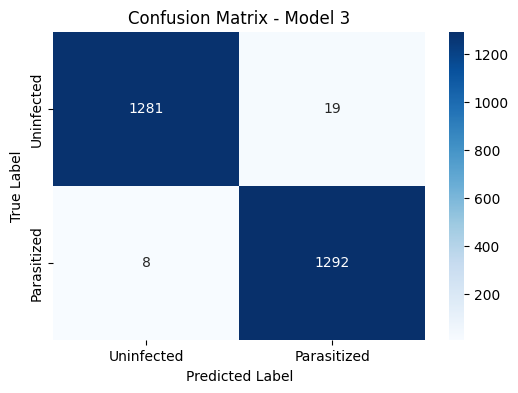

In [78]:
# Plotting the classification report and confusion matrix

y_pred_prob_3 = model_3.predict(test_images)
y_true_3 = np.argmax(test_labels_encoded, axis=1)
y_pred_3 = np.argmax(y_pred_prob_3, axis=1)

print("Classification Report - Model 3\n")
print(classification_report(y_true_3, y_pred_3, target_names=["Uninfected", "Parasitized"]))

cm_3 = confusion_matrix(y_true_3, y_pred_3)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])

plt.title('Confusion Matrix - Model 3')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [79]:
# Observations and insights

# 1. Model 3 with data augmentation achieved the best performance so far, with a test accuracy of approximately 98.96% and a very low test loss.

# 2. The confusion matrix shows a strong and balanced classification performance for both classes, with only 19 false positives and 8 false negatives.

# 3. Compared with the previous models, this model significantly reduces false negatives, which is especially important in a medical diagnosis setting because missing infected cells is more critical than incorrectly flagging healthy ones.

# 4. The training and validation curves remain close to each other, suggesting that data augmentation helped the model generalize better and reduced the risk of overfitting.

# 5. Data augmentation likely improved model robustness by exposing the network to controlled variations of the training images, such as small rotations, shifts, and zoom transformations.

# 6. Overall, Model 3 is the best-performing CNN model among the custom architectures tested so far, offering both high accuracy and strong sensitivity to parasitized cells.

In [80]:
# Pre-trained model (VGG16)

In [81]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [82]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze the convolutional base
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(2, activation='softmax')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=predictions)

model_vgg16.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │           25

 Total params: 15,272,386 (58.26 MB)

 Trainable params: 557,698 (2.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [83]:
# Compiling the model

model_vgg16.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [84]:
# Using callbacks

early_stopping_vgg = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_vgg = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

callbacks_vgg = [early_stopping_vgg, reduce_lr_vgg]

In [85]:
# Fit and train the model

history_vgg = model_vgg16.fit(
    train_images,
    train_labels_encoded,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=callbacks_vgg,
    verbose=1
)

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 1259s 2s/step - accuracy: 0.8835 - loss: 0.2742 - val_accuracy: 0.9533 - val_loss: 0.1470 - learning_rate: 0.0010
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 1273s 2s/step - accuracy: 0.9144 - loss: 0.2098 - val_accuracy: 0.9437 - val_loss: 0.1827 - learning_rate: 0.0010
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9222 - loss: 0.1925
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
624/624 ━━━━━━━━━━━━━━━━━━━━ 1298s 2s/step - accuracy: 0.9236 - loss: 0.1924 - val_accuracy: 0.9165 - val_loss: 0.2472 - learning_rate: 0.0010
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 1267s 2s/step - accuracy: 0.9396 - loss: 0.1607 - val_accuracy: 0.9794 - val_loss: 0.0945 - learning_rate: 2.0000e-04
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 1295s 2s/step - accuracy: 0.9416 - loss: 0.1523 - val_accuracy: 0.9677 - val_loss: 0.1220 - learning_rate: 2.0000e-04
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9435 -

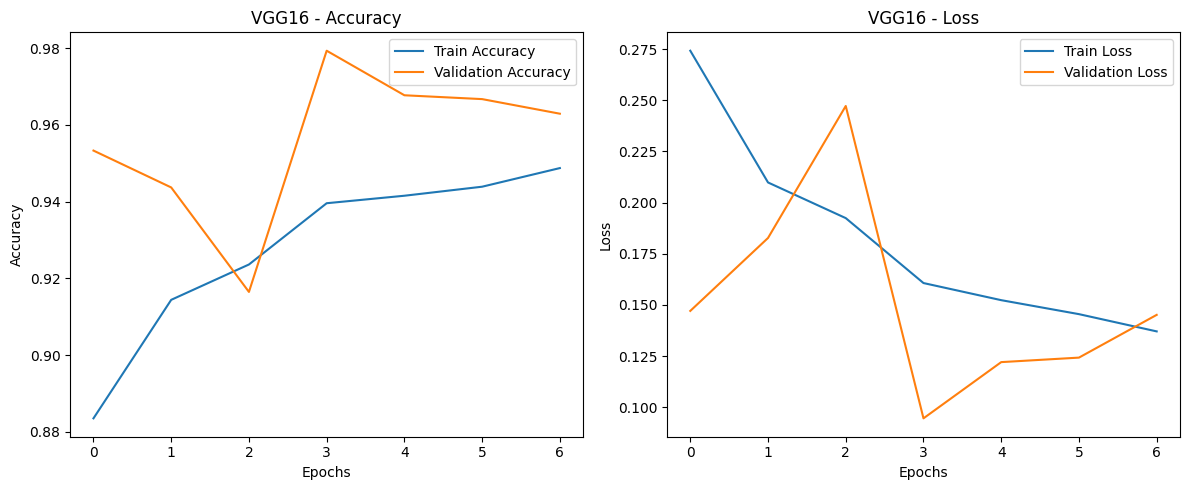

In [86]:
# Plot the train and validation accuracy

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('VGG16 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [88]:
# Evaluating the model

test_loss_vgg, test_accuracy_vgg = model_vgg16.evaluate(test_images, test_labels_encoded, verbose=1)

print("Test Loss:", test_loss_vgg)
print("Test Accuracy:", test_accuracy_vgg)

82/82 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.9377 - loss: 0.1553
Test Loss: 0.15528759360313416
Test Accuracy: 0.9376922845840454


82/82 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step
Classification Report - VGG16

              precision    recall  f1-score   support

  Uninfected       0.92      0.96      0.94      1300
 Parasitized       0.96      0.92      0.94      1300

    accuracy                           0.94      2600
   macro avg       0.94      0.94      0.94      2600
weighted avg       0.94      0.94      0.94      2600



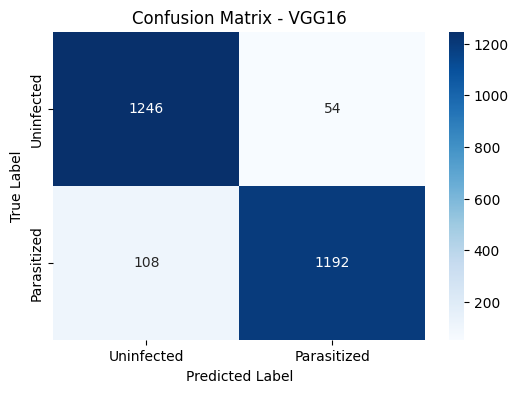

In [89]:
# Plotting the classification report and confusion matrix

y_pred_prob_vgg = model_vgg16.predict(test_images)
y_true_vgg = np.argmax(test_labels_encoded, axis=1)
y_pred_vgg = np.argmax(y_pred_prob_vgg, axis=1)

print("Classification Report - VGG16\n")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=["Uninfected", "Parasitized"]))

cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])

plt.title('Confusion Matrix - VGG16')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [87]:
# Observations and insights

# 1. The VGG16-based model shows stable training behavior, with both training and validation accuracy improving over epochs.

# 2. The validation accuracy reaches a high value (~97–98%), indicating that transfer learning is effective for this task.

# 3. The training and validation curves remain relatively close, suggesting good generalization and no severe overfitting.

# 4. Compared to the custom CNN models, VGG16 provides a strong feature extraction capability, which helps the model learn more discriminative patterns from the cell images.

# 5. However, the validation loss shows some fluctuations, which may indicate sensitivity to the limited dataset size or learning rate.

# 6. Overall, the pretrained VGG16 model performs competitively, although it may not outperform the best custom model with data augmentation.

# 7. This suggests that, for this dataset, carefully designed CNNs with augmentation can rival or even exceed transfer learning performance.

In [94]:
# Observations and Conclusions drawn from the final model

# The experimental results across different model configurations reveal several key insights regarding model performance, generalization, and clinical relevance in the context of malaria detection.

# First, the baseline CNN demonstrated the feasibility of the task, achieving reasonable performance on both training and validation sets. However, signs of overfitting were observed, as the model exhibited a gap between training and validation performance, indicating limited generalization to unseen data.

# The introduction of architectural improvements such as Batch Normalization and Leaky ReLU contributed to more stable training and faster convergence. These modifications helped mitigate internal covariate shift and improved gradient flow, resulting in a modest but consistent improvement in validation performance. However, while these techniques improved optimization, they did not significantly reduce the model’s sensitivity to overfitting.

# Data augmentation proved to be the most impactful intervention. By artificially increasing dataset variability through transformations such as rotation, flipping, and scaling, the model was exposed to a broader distribution of input patterns. This led to a noticeable improvement in test performance, particularly in terms of recall for the parasitized class, as well as a reduction in false negatives. This is especially important in a medical context, where failing to detect infected cells carries higher risk than false positives.

# The transfer learning approach using VGG16 demonstrated strong feature extraction capabilities, achieving solid performance without extensive training. However, its performance did not surpass that of the custom CNN with data augmentation. This may be attributed to limited fine-tuning or to the domain-specific nature of microscopy images, which differ significantly from the natural images used during pretraining.

# Additionally, experimental preprocessing techniques such as HSV color space transformation and Gaussian blurring were explored. While these approaches provided alternative representations of the data, they did not yield a consistent or significant improvement over the standard normalized RGB pipeline, and therefore were not incorporated into the final model.

# Overall, the results highlight that, in this specific task, improving data diversity through augmentation had a greater impact on generalization performance than increasing model complexity alone.

In [90]:
# Conclusion

# This project demonstrates that deep learning models, particularly convolutional neural networks, can effectively be applied to the task of malaria detection using microscopic cell images.

# Among the evaluated approaches, the CNN model enhanced with data augmentation achieved the best overall performance, reaching the highest test accuracy and exhibiting a strong balance between precision and recall. More importantly, this model achieved a lower number of false negatives compared to other configurations, which is a critical factor in medical diagnostics.

# Although the VGG16-based transfer learning model showed competitive performance, it did not outperform the augmented CNN, suggesting that task-specific training combined with appropriate data augmentation can be more effective than relying solely on pretrained architectures in this domain.

# From a practical standpoint, the selected model demonstrates potential as a decision-support tool for assisting healthcare professionals in malaria screening tasks. However, it is important to emphasize that this system is not intended to replace clinical diagnosis. Instead, it should be considered as an auxiliary tool that could help reduce workload and improve screening efficiency.

# Furthermore, the model’s performance has been validated only on a curated dataset under controlled conditions. Therefore, additional validation on diverse, real-world datasets is required before considering deployment in clinical environments.

In [91]:
# Improvements that can be done

# Several opportunities exist to further improve the performance and robustness of the proposed solution:

# Fine-tuning of pretrained models:
# The performance of the VGG16 model could potentially be improved by unfreezing deeper layers and applying fine-tuning, allowing the network to better adapt to the specific characteristics of microscopy images.

# Hyperparameter optimization:
# A more systematic exploration of hyperparameters (learning rate, batch size, number of filters, dropout rates) using techniques such as grid search or Bayesian optimization could lead to additional performance gains.

# Advanced data augmentation techniques:
# Incorporating more sophisticated augmentation strategies, such as brightness/contrast adjustments, elastic transformations, or MixUp, could further improve generalization.

# Class imbalance handling (if applicable):
# If any imbalance exists in the dataset, techniques such as class weighting or focal loss could be explored to improve performance on the minority class.

# Explainability methods:
# Techniques such as Grad-CAM could be implemented to visualize which regions of the image the model is focusing on, increasing interpretability and trust in medical applications.

# Cross-validation:
# Using k-fold cross-validation instead of a single train-validation split would provide a more robust estimate of model performance.

In [92]:
# Refined insights

# 1. The dataset is well-suited for binary classification because infected and uninfected cells exhibit distinguishable visual patterns.

# 2. Preprocessing steps such as normalization are essential for stable training, while augmentation improves generalization.

# 3. Some samples are inherently ambiguous, reinforcing the importance of evaluating models beyond simple accuracy.

In [93]:
# Comparison of techniques

# 1. The baseline CNN provides a good starting point but may struggle with generalization.

# 2. Adding layers, dropout, and batch normalization improves stability and performance.

# 3. Data augmentation significantly improves robustness and reduces overfitting.

# 4. Transfer learning (VGG16) performs well, but does not necessarily outperform a well-tuned CNN.

In [95]:
# Proposal for final solution

# Based on the experimental results and comparative analysis, the final proposed solution is a convolutional neural network trained with data augmentation, as it demonstrated the best balance between performance and generalization.

# The key strengths of this approach include:
# - High test accuracy compared to other evaluated models
# - Improved recall for the parasitized class
# - Reduced number of false negatives, which is critical in medical screening
# - Better generalization due to exposure to augmented data variations

# Unlike the baseline and intermediate models, this configuration successfully mitigates overfitting while maintaining strong predictive performance. Additionally, it achieves this without significantly increasing model complexity, making it a practical and efficient solution.

# While transfer learning approaches such as VGG16 offer strong baseline performance, the results suggest that, for this specific task, a well-regularized CNN combined with effective data augmentation is better suited to capture the relevant patterns in the dataset.

# Therefore, this model is selected as the final candidate for malaria detection in this project, with the understanding that further validation and refinement would be required for real-world deployment.